# Learning state estimation through one robot

This lab develops the main ideas of state estimation through one consistent robot example. Run every cell from top to bottom. Each algorithm estimates the same two-state robot:

$$x=[p,\;v]^T$$

where $p$ is position (m) and $v$ is velocity (m/s). The known input $u$ is commanded acceleration. The real robot has nonlinear drag $-c v|v|$, disturbances, noisy GPS position, and a nonlinear range sensor looking at a landmark.

The linear filters intentionally use a simpler constant-acceleration model. The EKFs know about nonlinear drag and/or the nonlinear range measurement. This lets us see both model mismatch and the value of nonlinear estimation.

## The learning path

We will move from the easiest assumptions to the most realistic case:

**linear and continuous → linear and sampled → nonlinear and sampled → deterministic observers**

At every stage, ask four questions: What model predicts the state? What does the sensor predict? How is the disagreement calculated? How is uncertainty or convergence handled?

> Study one section at a time. Read the idea, follow the derivation, inspect the code comments, run the cell, and explain the plot in your own words before continuing.


In [2]:
# NumPy provides vectors, matrices, random noise, and linear algebra.
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')
# A fixed seed makes the simulated noise identical every time you run the notebook.
# This is important while learning because changes in a plot then come from your code.
rng = np.random.default_rng(7)

def rmse(estimate, truth):
    # RMSE is a single summary of typical estimation error. axis=0 computes
    # one value for position and one value for velocity. Smaller is better.
    return np.sqrt(np.mean((estimate - truth)**2, axis=0))

def plot_estimate(t, truth, estimate, title, measurements=None, sigma=None):
    # Make two aligned panels: position on top and velocity below.
    fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    labels = ['position [m]', 'velocity [m/s]']
    for j in range(2):
        ax[j].plot(t, truth[:, j], 'k', lw=2, label='true')
        ax[j].plot(t, estimate[:, j], 'C1', lw=1.8, label='estimate')
        if sigma is not None:
            # sqrt(diag(P)) is the filter's estimated 1-sigma uncertainty.
            # For a well-tuned Gaussian filter, truth should usually stay inside ±2 sigma.
            ax[j].fill_between(t, estimate[:, j]-2*sigma[:, j],
                               estimate[:, j]+2*sigma[:, j],
                               color='C1', alpha=.18, label=r'$\pm2\sigma$')
        if j == 0 and measurements is not None:
            mt, mz = measurements
            ax[j].scatter(mt, mz, s=13, alpha=.35, label='position measurements')
        ax[j].set_ylabel(labels[j])
        ax[j].legend(loc='best')
    ax[-1].set_xlabel('time [s]')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 0. Create the real system and sensor data

Our lesson begins with the physical system. Before choosing a filter, we must decide what the state contains, how the robot moves, what each sensor measures, and where uncertainty enters. The robot state is

$$x=[p,\;v]^T,$$

where $p$ is position and $v$ is velocity. The simulation uses a small time step to integrate the robot dynamics and generate the ground-truth trajectory.

The acceleration command $u(t)$ changes over time, causing the robot to accelerate, coast, and decelerate. Nonlinear drag models resistance that increases with the magnitude of velocity. Random process noise represents unmodeled disturbances, while sensor noise makes the GPS and range measurements realistic.

The truth follows

$$\dot p=v, \qquad \dot v=u-cv|v|+n_a.$$

GPS measures $z_p=p+w_p$. A landmark at $(L,d)$ gives the nonlinear range

$$z_r=\sqrt{(p-L)^2+d^2}+w_r.$$

The side offset $d$ keeps the range function smooth when the robot passes the landmark.

### From physical motion to equations

Writing the dynamics as a vector function gives

$$f_c(x,u)=\begin{bmatrix}v\\u-cv|v|\end{bmatrix}.$$

Euler–Maruyama integration over $\Delta t$ gives

$$p_{k+1}=p_k+v_k\Delta t,$$
$$v_{k+1}=v_k+(u_k-cv_k|v_k|)\Delta t+\sqrt{q_a\Delta t}\,\epsilon_k,$$

where $\epsilon_k\sim\mathcal N(0,1)$. The factor $\sqrt{\Delta t}$ is required because white-noise **variance** accumulates in proportion to time. The sensor simulation uses

$$z_{p,k}=p_k+\sigma_p\epsilon_{p,k},\qquad z_{r,k}=h(x_k)+\sigma_r\epsilon_{r,k},$$

with $h(x)=\sqrt{(p-L)^2+d^2}$. These equations correspond directly to the updates of `truth`, `gps`, and `range_meas` in the following code.

![display](piecewise_robot_simulation_explained.gif)

The generated variables are:

- `truth`: the actual robot position and velocity.
- `u`: the commanded acceleration.
- `gps`: noisy position measurements.
- `true_range`: ideal distance to the landmark.
- `range_meas`: noisy range measurements.
- `t`: simulation timestamps.

### What to notice in the first plot

- The control command changes before velocity changes; velocity then causes position to change.
- GPS samples scatter around true position because measurement noise affects individual readings.
- Range decreases as the robot approaches the landmark and increases after it passes. One range can correspond to two possible positions, so range-only estimation can be locally ambiguous.

This simulation is our hidden real world. Every estimator receives commands and selected sensor readings, but never receives `truth`. We use `truth` only afterward to evaluate performance.


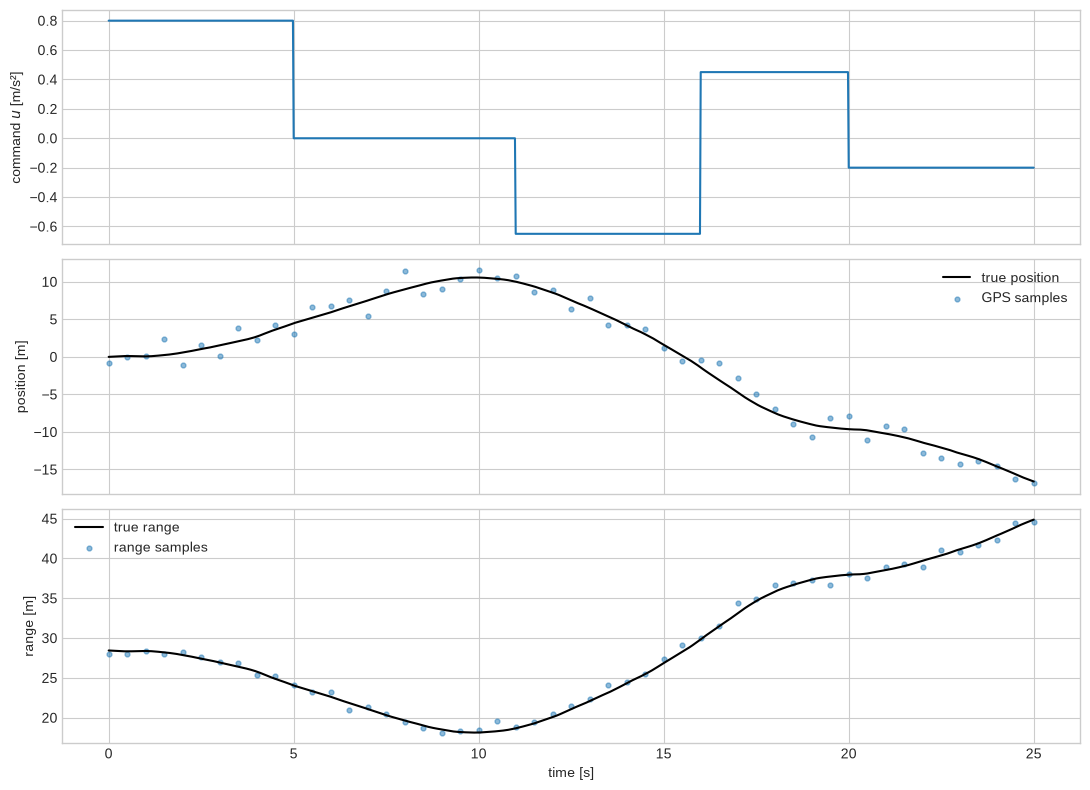

In [3]:
# Simulation clock: dt=0.02 s means that truth is integrated at 50 Hz.
dt = 0.02
T = 25.0
t = np.arange(0.0, T + dt, dt)
N = len(t)
# Physical and sensor parameters. `drag` makes the true dynamics nonlinear.
drag = 0.035
q_acc = 0.18                 # acceleration-noise spectral density
gps_std = 1.2
range_std = 0.55
landmark_x, landmark_side = 28.0, 5.0

def command(time):
    # A piecewise acceleration command makes the robot speed up, coast, and slow down.
    if time < 5: return 0.8
    if time < 11: return 0.0
    if time < 16: return -0.65
    if time < 20: return 0.45
    return -0.2

# Evaluate the commanded acceleration at every simulation time.
u = np.array([command(tt) for tt in t])
# `truth[k]` holds [true position, true velocity] at time index k.
truth = np.zeros((N, 2))
truth[0] = [0.0, 0.2]
for k in range(N-1):
    p, v = truth[k]
    # Euler-Maruyama: dv has deterministic acceleration and stochastic increment.
    # Integrate position: p_next = p + v*dt.
    truth[k+1, 0] = p + v*dt
    # Integrate velocity. sqrt(q_acc*dt)*normal is the correct scaling for
    # a continuous white acceleration disturbance over an interval dt.
    truth[k+1, 1] = v + (u[k] - drag*v*abs(v))*dt + np.sqrt(q_acc*dt)*rng.normal()

# Produce synthetic sensor logs. The estimator is never given `truth` directly.
gps = truth[:, 0] + gps_std*rng.normal(size=N)
# Euclidean distance from robot (p,0) to the fixed landmark (landmark_x, side).
true_range = np.sqrt((truth[:, 0]-landmark_x)**2 + landmark_side**2)
range_meas = true_range + range_std*rng.normal(size=N)

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
ax[0].plot(t, u); ax[0].set_ylabel('command $u$ [m/s²]')
ax[1].plot(t, truth[:,0], 'k', label='true position')
ax[1].scatter(t[::25], gps[::25], s=12, alpha=.5, label='GPS samples'); ax[1].legend()
ax[1].set_ylabel('position [m]')
ax[2].plot(t, true_range, 'k', label='true range')
ax[2].scatter(t[::25], range_meas[::25], s=12, alpha=.5, label='range samples')
ax[2].set_ylabel('range [m]'); ax[2].set_xlabel('time [s]'); ax[2].legend()
plt.tight_layout(); plt.show()

## 1. Continuous-time Kalman filter (Sections 2.2–2.3)

We begin with the simplest estimation setting: the motion model and sensor are linear, and information is available continuously. We pretend the robot has linear dynamics $\dot x=A_cx+B_cu+n_c$ and that GPS is available continuously. Euler integration implements

$$\dot{\hat x}=A_c\hat x+B_cu+K_c(z-C\hat x),$$
$$\dot P=A_cP+PA_c^T+Q_c-PC^TR_c^{-1}CP.$$

Here `Rc` is treated as a continuous measurement-noise intensity. The correction is a **rate**, so it is multiplied by `dt` during Euler integration. Continuous noise intensity and the variance of an individual discrete sensor sample are related but are not interchangeable; Section 2.4 handles discrete sample variance explicitly.

### Build the estimator step by step

Ignoring nonlinear drag for this first estimator gives

$$\begin{bmatrix}\dot p\\\dot v\end{bmatrix}=\underbrace{\begin{bmatrix}0&1\\0&0\end{bmatrix}}_{A_c}\begin{bmatrix}p\\v\end{bmatrix}+\underbrace{\begin{bmatrix}0\\1\end{bmatrix}}_{B_c}u+n_c.$$

GPS measures position, so $z=Cx+w$ with $C=[1\;0]$. The predicted measurement and innovation are

$$\hat z=C\hat x=\hat p,\qquad \tilde z=z-\hat z=z-\hat p.$$

The gain $K_c=PC^TR_c^{-1}$ is a $2\times1$ vector, so one GPS residual corrects both $\hat p$ and $\hat v$. Euler integration converts each differential equation into code:

$$\hat x_{k+1}\approx\hat x_k+\Delta t\left(A_c\hat x_k+B_cu_k+K_{c,k}\tilde z_k\right),$$
$$P_{k+1}\approx P_k+\Delta t\left(A_cP_k+P_kA_c^T+Q_c-P_kC^TR_c^{-1}CP_k\right).$$

The first three covariance terms propagate/add uncertainty; the negative term removes uncertainty using continuous measurement information.
![gif](continuous_time_kalman_filter_explained.gif)

### What to observe after running the cell

The estimate begins at the wrong position but is pulled toward the truth by repeated innovations. The orange uncertainty band should contract initially. Velocity is corrected even though GPS measures only position because position and velocity uncertainty become correlated through the motion model.

### When this formulation is useful

Use a continuous-time KF mainly for analysis or when both the model and measurement information are naturally modeled as continuous signals. Most digital robotic systems instead use the discrete or continuous-discrete forms below.


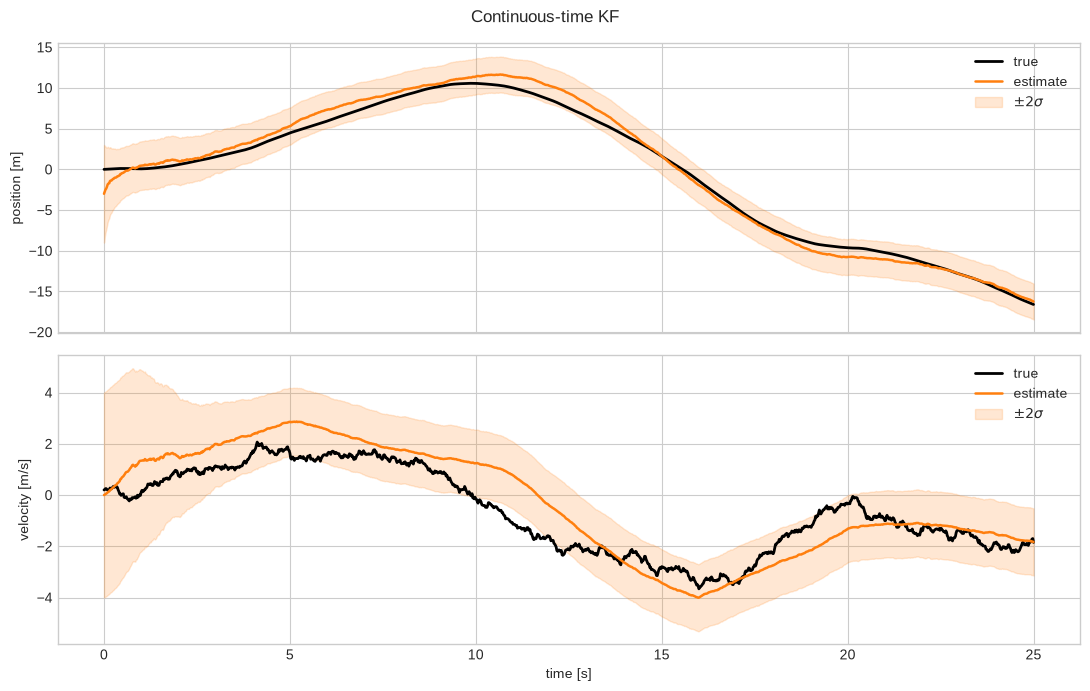

RMSE [position, velocity] = [0.8898 0.8621]


In [4]:
# Linear state model for x=[p,v]: p_dot=v and v_dot=u.
# Matrix shapes: Ac(2x2), Bc(2,), C(1x2), P(2x2), K(2x1).
Ac = np.array([[0., 1.], [0., 0.]])
Bc = np.array([0., 1.])
C = np.array([[1., 0.]])
# Qc says that unknown process disturbance enters the velocity equation.
Qc = np.array([[0., 0.], [0., q_acc]])
Rc = gps_std**2            # continuous measurement-noise intensity

# Start deliberately wrong: estimated position=-3 m while truth starts near 0 m.
xhat_ct = np.zeros((N, 2)); xhat_ct[0] = [-3., 0.]
# Initial variances 9 and 4 mean standard deviations 3 m and 2 m/s.
P_ct = np.zeros((N, 2, 2)); P_ct[0] = np.diag([9., 4.])
K_history = np.zeros((N, 2))
for k in range(N-1):
    # The Kalman gain converts one position residual into corrections for
    # both position and velocity. `/Rc` is scalar division here.
    Kc = P_ct[k] @ C.T / Rc
    # innovation = actual sensor value - predicted sensor value.
    innovation = gps[k] - (C @ xhat_ct[k])[0]
    xdot = Ac @ xhat_ct[k] + Bc*u[k] + Kc[:,0]*innovation
    # Riccati equation: dynamics/process noise grow uncertainty; continuous
    # measurement information (the final negative term) reduces it.
    Pdot = Ac@P_ct[k] + P_ct[k]@Ac.T + Qc - P_ct[k]@C.T@C@P_ct[k]/Rc
    xhat_ct[k+1] = xhat_ct[k] + dt*xdot
    # Average with the transpose to remove tiny floating-point asymmetry.
    P_ct[k+1] = 0.5*((P_ct[k] + dt*Pdot) + (P_ct[k] + dt*Pdot).T)
    K_history[k] = Kc[:,0]

plot_estimate(t, truth, xhat_ct, 'Continuous-time KF', sigma=np.sqrt(np.maximum(np.diagonal(P_ct, axis1=1, axis2=2), 0)))
print('RMSE [position, velocity] =', rmse(xhat_ct, truth))

## 2. Discrete-time Kalman filter (Section 2.4)

A real computer does not receive infinitely many measurements. Our next question is: what changes when GPS arrives only once every 0.5 s? Between measurements we use the exact constant-acceleration transition

$$A=\begin{bmatrix}1&h\\0&1\end{bmatrix},\quad B=\begin{bmatrix}h^2/2\\h\end{bmatrix}.$$

Watch the covariance grow during prediction and shrink at every update.

### Build the estimator step by step

Assuming acceleration is constant over one sample interval $h$, integrate $\dot v=u$ and $\dot p=v$:

$$v_k=v_{k-1}+hu_{k-1},$$
$$p_k=p_{k-1}+hv_{k-1}+\frac12h^2u_{k-1}.$$

Stacking these equations produces $x_k=Ax_{k-1}+Bu_{k-1}+n_{k-1}$ with the matrices above. Continuous white acceleration noise with intensity $q_a$ accumulates into

$$Q=q_a\begin{bmatrix}h^3/3&h^2/2\\h^2/2&h\end{bmatrix}.$$

The two code phases are then

**Prediction**
$$\hat x_k^-=A\hat x_{k-1}^++Bu_{k-1},\qquad P_k^-=AP_{k-1}^+A^T+Q.$$

**GPS update**
$$\tilde z_k=z_k-C\hat x_k^-,\qquad S_k=CP_k^-C^T+R,$$
$$K_k=P_k^-C^TS_k^{-1},\qquad \hat x_k^+=\hat x_k^-+K_k\tilde z_k.$$

The code uses the numerically robust Joseph covariance update

$$P_k^+=(I-K_kC)P_k^-(I-K_kC)^T+K_kRK_k^T.$$

![](discrete_time_kalman_filter_explained.gif)

### Follow one complete cycle

Immediately after a GPS update, the superscript $+$ means posterior: the measurement has been used. Prediction creates $\hat x_k^-$ and $P_k^-$. The new innovation then creates the next posterior $\hat x_k^+$ and $P_k^+$. This repeating **predict → compare → correct** cycle is the heart of the Kalman filter.

### What to observe and when to use it

The estimate changes only at represented sample times, and uncertainty falls after measurements. Use a discrete KF when both the dynamics and sensors are represented at fixed discrete intervals and the model is linear. It is often the simplest correct choice for sampled linear systems.


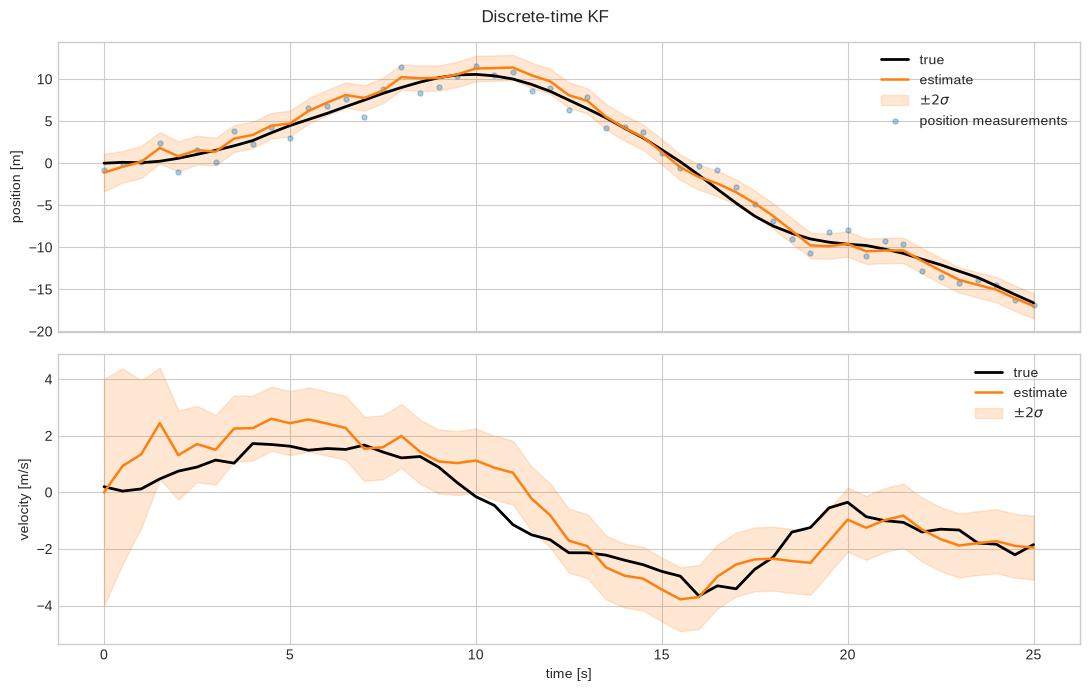

RMSE at GPS times = [0.7757 0.7875]


In [5]:
# Keep only every 25th GPS sample: one measurement every 0.5 seconds.
gps_step = 25                         # 25*0.02 = 0.5 s
gps_idx = np.arange(0, N, gps_step)
h = gps_step*dt
# Exact discrete constant-acceleration matrices for an interval h.
# A propagates the old state; B maps acceleration into position and velocity.
A = np.array([[1., h], [0., 1.]])
B = np.array([0.5*h*h, h])
# Discrete Q is the accumulated effect of continuous acceleration noise.
# Its off-diagonal values couple position uncertainty and velocity uncertainty.
Q = q_acc*np.array([[h**3/3, h**2/2], [h**2/2, h]])
R = np.array([[gps_std**2]])

# Lists store posterior values so that we can plot and inspect them later.
x_updates = []; P_updates = []; innovations = []; gains = []
xk = np.array([-3., 0.]); Pk = np.diag([9., 4.])
for j, k in enumerate(gps_idx):
    if j > 0:
        # PREDICTION: move the previous posterior to the current sensor time.
        uk = np.mean(u[gps_idx[j-1]:k])
        xk = A@xk + B*uk
        Pk = A@Pk@A.T + Q
    # UPDATE: compare GPS with the position predicted by C@xk.
    residual = gps[k] - (C@xk)[0]
    # S is expected residual variance: projected state uncertainty + sensor noise.
    S = C@Pk@C.T + R
    # K decides how much of the residual enters each state component.
    K = Pk@C.T@np.linalg.inv(S)
    xk = xk + K[:,0]*residual
    I_KC = np.eye(2)-K@C
    # Joseph covariance update is algebraically equivalent to (I-KC)P,
    # but better preserves symmetry and non-negative uncertainty numerically.
    Pk = I_KC@Pk@I_KC.T + K@R@K.T  # Joseph form
    x_updates.append(xk.copy()); P_updates.append(Pk.copy())
    innovations.append(residual); gains.append(K[:,0])
x_updates, P_updates = np.array(x_updates), np.array(P_updates)

plot_estimate(t[gps_idx], truth[gps_idx], x_updates, 'Discrete-time KF',
              measurements=(t[gps_idx], gps[gps_idx]),
              sigma=np.sqrt(np.diagonal(P_updates, axis1=1, axis2=2)))
print('RMSE at GPS times =', rmse(x_updates, truth[gps_idx]))

## 3. Continuous-discrete Kalman filter (Section 2.5)

The robot moves between sensor messages, so stopping the model between updates would be wrong. We now let the state and covariance flow continuously, but update only when GPS arrives. We deliberately make the GPS times irregular. This is the usual architecture for a continuously moving robot with sampled sensors.

### Build the estimator step by step

Between two measurement times $t_{k-1}$ and $t_k$, there is no correction because no new information is available:

$$\dot{\hat x}=A_c\hat x+B_cu,\qquad \dot P=A_cP+PA_c^T+Q_c.$$

The notebook integrates these equations at every small simulation step. If `measurement_mask[k+1]` is false, propagation is the only operation. If it is true, the discrete GPS update is applied:

$$\tilde z_k=z_k-C\hat x_k^-,\quad S_k=CP_k^-C^T+R,\quad K_k=P_k^-C^TS_k^{-1},$$
$$\hat x_k^+=\hat x_k^-+K_k\tilde z_k,\quad P_k^+=(I-K_kC)P_k^-.$$

A longer gap between measurements means the positive $Q_c$ term acts for longer, so $P_k^-$ becomes larger before the next correction.

![](continuous_discrete_kf_irregular_gps.gif)

### What to observe after running the cell

Between GPS arrivals, the estimate moves according to physics while uncertainty grows. At a GPS arrival, the state and covariance jump through a discrete correction. Unequal gaps produce unequal prior uncertainty.

### When this formulation is useful

Use it when motion is described by differential equations but measurements arrive as timestamped packets, possibly irregularly. This pattern is common for GPS, cameras, acoustic sensors, and multi-rate robotic systems.


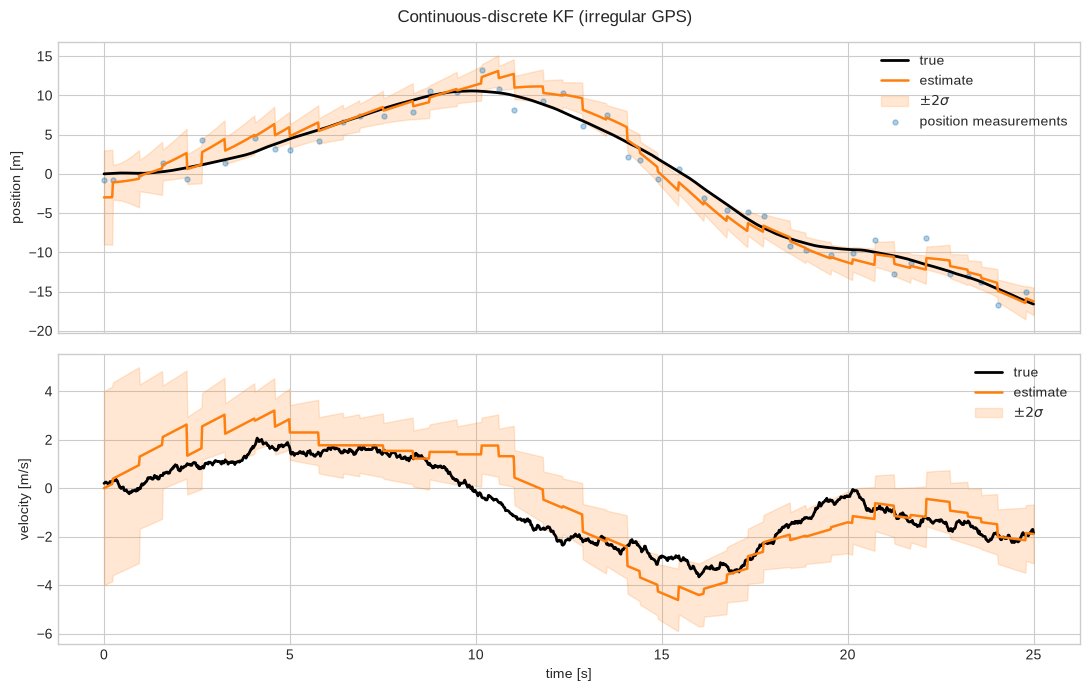

RMSE = [1.3168 0.9851]


In [6]:
# Build a Boolean schedule of irregular GPS arrival times. True means that
# a measurement is available at that index; False means propagation only.
rng_times = np.random.default_rng(21)
measurement_mask = np.zeros(N, dtype=bool)
next_time = 0.25
while next_time <= T:
    measurement_mask[np.argmin(abs(t-next_time))] = True
    next_time += rng_times.uniform(0.35, 0.8)
measurement_mask[0] = True

xhat_cd = np.zeros((N,2)); xhat_cd[0] = [-3.,0.]
P_cd = np.zeros((N,2,2)); P_cd[0] = np.diag([9.,4.])
for k in range(N-1):
    # PROPAGATION runs at every small dt, whether or not GPS is available.
    # Continuous propagation is approximated here with one Euler step.
    xhat_cd[k+1] = xhat_cd[k] + dt*(Ac@xhat_cd[k] + Bc*u[k])
    P_cd[k+1] = P_cd[k] + dt*(Ac@P_cd[k] + P_cd[k]@Ac.T + Qc)
    if measurement_mask[k+1]:
        # CORRECTION is a discrete jump and runs only when GPS arrives.
        residual = gps[k+1] - (C@xhat_cd[k+1])[0]
        S = C@P_cd[k+1]@C.T + R
        K = P_cd[k+1]@C.T@np.linalg.inv(S)
        xhat_cd[k+1] += K[:,0]*residual
        J = np.eye(2)-K@C
        P_cd[k+1] = J@P_cd[k+1]@J.T + K@R@K.T

idx_irregular = np.flatnonzero(measurement_mask)
plot_estimate(t, truth, xhat_cd, 'Continuous-discrete KF (irregular GPS)',
              measurements=(t[idx_irregular], gps[idx_irregular]),
              sigma=np.sqrt(np.maximum(np.diagonal(P_cd,axis1=1,axis2=2),0)))
print('RMSE =', rmse(xhat_cd, truth))

## 4. Continuous-time EKF (Section 2.7)

The linear model ignores drag, and this creates systematic prediction error as speed increases. We therefore move to an Extended Kalman Filter. The estimator now knows the nonlinear drag. The state uses the nonlinear function $f_c(\hat x,u)$, while covariance uses its Jacobian

$$A_c=\frac{\partial f_c}{\partial x}=\begin{bmatrix}0&1\\0&-2c|\hat v|\end{bmatrix}.$$

GPS itself is linear here, so $C=[1,0]$. This is still an EKF because the motion model is nonlinear.

### From nonlinear motion to the EKF equations

The nonlinear model is

$$f_c(x,u)=\begin{bmatrix}f_1\\f_2\end{bmatrix}=\begin{bmatrix}v\\u-cv|v|\end{bmatrix}.$$

Differentiate each component with respect to $x=[p,v]^T$:

$$\frac{\partial f_1}{\partial p}=0,\quad \frac{\partial f_1}{\partial v}=1,$$
$$\frac{\partial f_2}{\partial p}=0,\quad \frac{\partial f_2}{\partial v}=-2c|v|.$$

Thus `F_cont(xhat)` evaluates the displayed Jacobian at the current estimated velocity $\hat v$. The state uses the full nonlinear function,

$$\dot{\hat x}=f_c(\hat x,u)+K_c[z-h(\hat x)],$$

while the covariance uses the local linear approximation,

$$\dot P=F_cP+PF_c^T+Q_c-PC^TR_c^{-1}CP.$$

This separation—nonlinear function for the state, Jacobian for uncertainty—is the defining EKF idea.
![](continuous_time_ekf_nonlinear_drag.gif)


### What changed from the ordinary KF?

The prediction is no longer $A_c\hat x+B_cu$; it is the nonlinear function $f_c(\hat x,u)$. The matrix $F_c$ is not a replacement for that function. It is only the local slope used to describe how a small estimation error and its covariance evolve. It must be recomputed as $\hat v$ changes.

### What to observe and when to use it

Accounting for drag should reduce velocity-model error compared with the linear model. Use a continuous EKF when nonlinear dynamics or measurements are continuously modeled and local linearization is acceptable. Remember that $P$ is approximate because the error model is only locally linear.


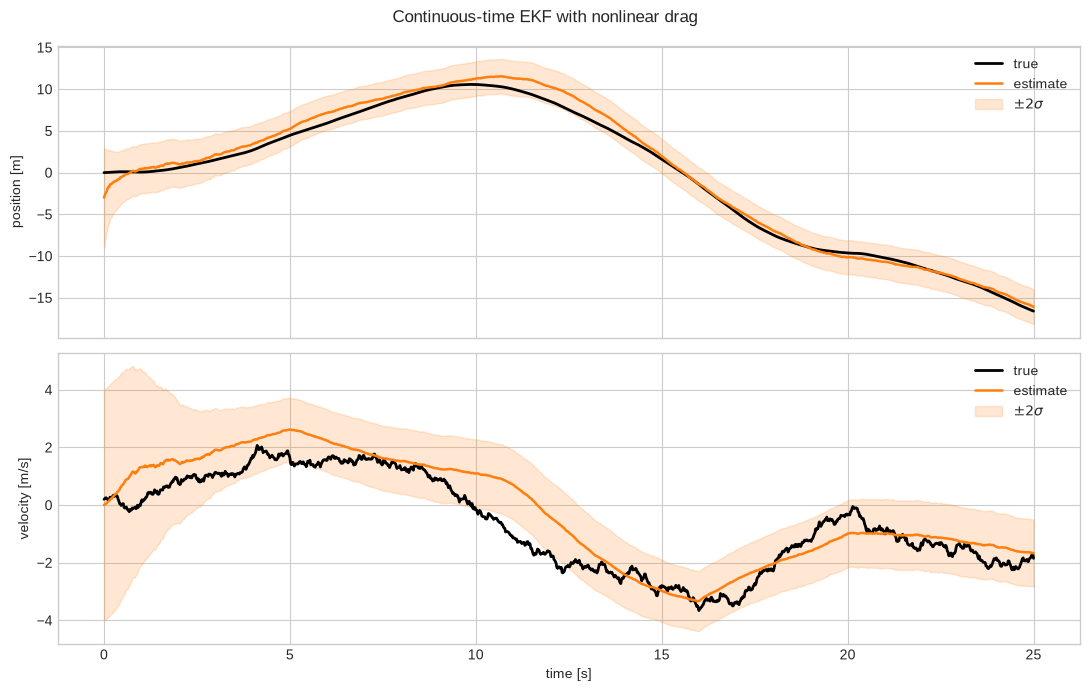

RMSE = [0.8193 0.745 ]


In [7]:
def f_cont(x, uk):
    # Nonlinear physical model used to propagate the STATE estimate.
    p, v = x
    return np.array([v, uk-drag*v*abs(v)])

def F_cont(x):
    # Jacobian df/dx used to propagate the COVARIANCE. For v*abs(v),
    # the derivative with respect to v is 2*abs(v) (away from v=0).
    v = x[1]
    return np.array([[0., 1.], [0., -2*drag*abs(v)]])

xhat_cekf = np.zeros((N,2)); xhat_cekf[0] = [-3.,0.]
P_cekf = np.zeros((N,2,2)); P_cekf[0] = np.diag([9.,4.])
for k in range(N-1):
    # Re-linearize around the CURRENT estimate. This changing Jacobian is
    # the main difference between an EKF and a linear KF.
    F = F_cont(xhat_cekf[k])
    Kc = P_cekf[k]@C.T/Rc
    residual = gps[k] - xhat_cekf[k,0]
    # The state uses nonlinear f_cont; only covariance uses linearized F.
    xhat_cekf[k+1] = xhat_cekf[k] + dt*(f_cont(xhat_cekf[k],u[k]) + Kc[:,0]*residual)
    Pdot = F@P_cekf[k] + P_cekf[k]@F.T + Qc - P_cekf[k]@C.T@C@P_cekf[k]/Rc
    P_cekf[k+1] = P_cekf[k] + dt*Pdot
    P_cekf[k+1] = .5*(P_cekf[k+1]+P_cekf[k+1].T)

plot_estimate(t, truth, xhat_cekf, 'Continuous-time EKF with nonlinear drag',
              sigma=np.sqrt(np.maximum(np.diagonal(P_cekf,axis1=1,axis2=2),0)))
print('RMSE =', rmse(xhat_cekf, truth))

## 5. Discrete-time EKF (Section 2.8)

Nonlinearity can also enter through the sensor. A landmark does not directly report position; it reports distance. We now use the nonlinear landmark range $h(x)$. The measurement Jacobian is

$$C_k=\begin{bmatrix}\frac{\hat p-L}{\sqrt{(\hat p-L)^2+d^2}}&0\end{bmatrix}.$$

The residual is in range units, and $K$ maps it into corrections of position and velocity.

### Build the estimator step by step

Over a sample interval $h$, define nonlinear acceleration $a(\hat v,u)=u-c\hat v|\hat v|$. The state prediction implemented in `f_discrete` is

$$\hat p_k^-=\hat p_{k-1}^+ +h\hat v_{k-1}^+ +\frac12h^2a,$$
$$\hat v_k^-=\hat v_{k-1}^+ +ha.$$

Since $\partial a/\partial v=-2c|v|$, differentiating this transition gives

$$F_k=\begin{bmatrix}1&h+\frac12h^2(-2c|\hat v|)\\0&1+h(-2c|\hat v|)\end{bmatrix}.$$

The range function is $h(x)=\sqrt{(p-L)^2+d^2}$. By the chain rule,

$$\frac{\partial h}{\partial p}=\frac{p-L}{\sqrt{(p-L)^2+d^2}},\qquad \frac{\partial h}{\partial v}=0.$$

The EKF therefore predicts the actual sensor with $h(\hat x_k^-)$ but uses its local slope $H_k$ in

$$P_k^-=F_kP_{k-1}^+F_k^T+Q,$$
$$\tilde z_k=z_k-h(\hat x_k^-),\quad S_k=H_kP_k^-H_k^T+R,$$
$$K_k=P_k^-H_k^TS_k^{-1},\quad \hat x_k^+=\hat x_k^-+K_k\tilde z_k.$$

Do not replace $h(\hat x)$ by $H\hat x$: $H$ is only the tangent slope at the current estimate.
![](discrete_ekf_nonlinear_landmark_range.gif)

### Follow the nonlinear update carefully

First predict a range with the full nonlinear function $h(\hat x_k^-)$. Then compare it with measured range. Only after forming that physical residual do we use $H_k$ to project covariance and calculate the gain. This distinction prevents the common mistake of treating $H_k\hat x$ as the nonlinear sensor prediction.

### What to observe and when to use it

The range update can correct velocity through cross-covariance even though its instantaneous Jacobian has a zero velocity column. Use a discrete EKF when nonlinear dynamics or sensors are sampled at discrete times. It works best with a reasonable initial estimate and mild nonlinearity around that estimate.


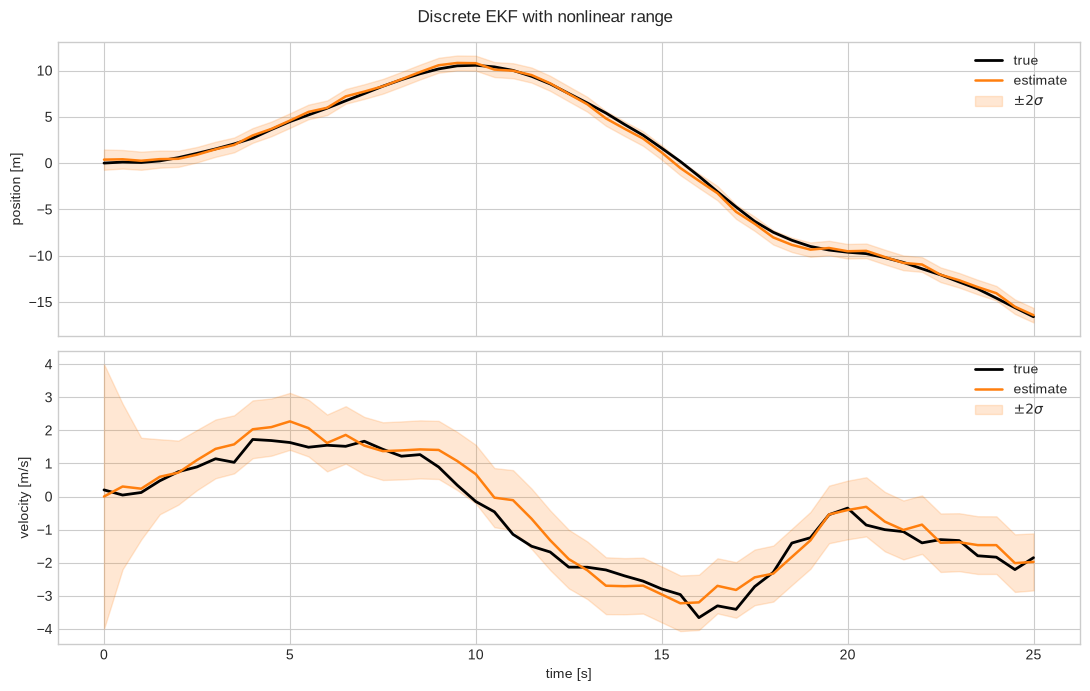

RMSE at range times = [0.3057 0.3954]


In [8]:
def f_discrete(x, uk, h):
    # Nonlinear state transition over h seconds. The same drag acceleration
    # affects both the position and velocity prediction.
    p, v = x
    a = uk-drag*v*abs(v)
    return np.array([p+h*v+0.5*h*h*a, v+h*a])

def F_discrete(x, h):
    # Jacobian of f_discrete with respect to [p,v]. It describes how a small
    # prior state error changes after nonlinear propagation.
    v = x[1]
    da_dv = -2*drag*abs(v)
    return np.array([[1., h+0.5*h*h*da_dv], [0., 1+h*da_dv]])

def h_range(x):
    # Nonlinear measurement prediction: distance from robot to landmark.
    return np.sqrt((x[0]-landmark_x)**2 + landmark_side**2)

def H_range(x):
    # Measurement Jacobian dh/dx, evaluated at the predicted state. The zero
    # says range has no instantaneous direct dependence on velocity.
    r = h_range(x)
    return np.array([[(x[0]-landmark_x)/r, 0.]])

range_step = 25; range_idx = np.arange(0,N,range_step); h_r = range_step*dt
Q_r = q_acc*np.array([[h_r**3/3,h_r**2/2],[h_r**2/2,h_r]])
R_r = np.array([[range_std**2]])
x_dekf=[]; P_dekf=[]
xk=np.array([-3.,0.]); Pk=np.diag([9.,4.])
for j,k in enumerate(range_idx):
    if j>0:
        # EKF prediction: nonlinear state propagation and linearized covariance.
        uk=np.mean(u[range_idx[j-1]:k])
        F=F_discrete(xk,h_r)
        xk=f_discrete(xk,uk,h_r)
        Pk=F@Pk@F.T+Q_r
    # Re-linearize the nonlinear sensor at the predicted state before update.
    H=H_range(xk)
    # IMPORTANT: predict the sensor with h_range(xk), not with H@xk.
    # H is only a local slope used for uncertainty and gain calculations.
    residual=range_meas[k]-h_range(xk)
    S=H@Pk@H.T+R_r
    K=Pk@H.T@np.linalg.inv(S)
    xk=xk+K[:,0]*residual
    J=np.eye(2)-K@H
    Pk=J@Pk@J.T+K@R_r@K.T
    x_dekf.append(xk.copy()); P_dekf.append(Pk.copy())
x_dekf=np.array(x_dekf); P_dekf=np.array(P_dekf)
plot_estimate(t[range_idx],truth[range_idx],x_dekf,'Discrete EKF with nonlinear range',
              sigma=np.sqrt(np.diagonal(P_dekf,axis1=1,axis2=2)))
print('RMSE at range times =',rmse(x_dekf,truth[range_idx]))

## 6. Continuous-discrete EKF (Section 2.9)

We can now assemble the most realistic estimator in this lesson: nonlinear continuous motion between measurements and nonlinear corrections whenever irregular range measurements arrive. This combines nonlinear continuous propagation with irregular discrete range updates. It is closest to a typical real robot estimator.

### Build the estimator step by step

Starting immediately after an update at $t_{k-1}$, integrate

$$\dot{\hat x}(t)=f_c(\hat x(t),u(t)),$$
$$\dot P(t)=F_c(\hat x(t))P(t)+P(t)F_c(\hat x(t))^T+Q_c.$$

Both $\hat x$ and the linearization $F_c$ change during propagation. When an irregular range sample arrives at $t_k$, compute

$$\tilde z_k=z_{r,k}-h(\hat x_k^-),\qquad H_k=\left.\frac{\partial h}{\partial x}\right|_{\hat x_k^-},$$
$$S_k=H_kP_k^-H_k^T+R_r,\qquad K_k=P_k^-H_k^TS_k^{-1},$$
$$\hat x_k^+=\hat x_k^-+K_k\tilde z_k.$$

In the code, the continuous equations execute unconditionally inside the loop, while the equations above execute only inside `if range_mask[k+1]`.

![](continuous_discrete_ekf_irregular_range.gif)

### Read the algorithm as two clocks

The fast clock propagates nonlinear state and covariance every `dt`. The slower irregular sensor clock enters the `if range_mask` block and performs a correction. A real robot implements the same idea with timestamps and sensor callbacks.

### What to observe and when to use it

The estimate flows smoothly between range messages and jumps slightly at messages. Use this architecture for many real navigation systems: nonlinear continuous vehicle/IMU dynamics combined with asynchronous GPS, vision, depth, range, or landmark observations.


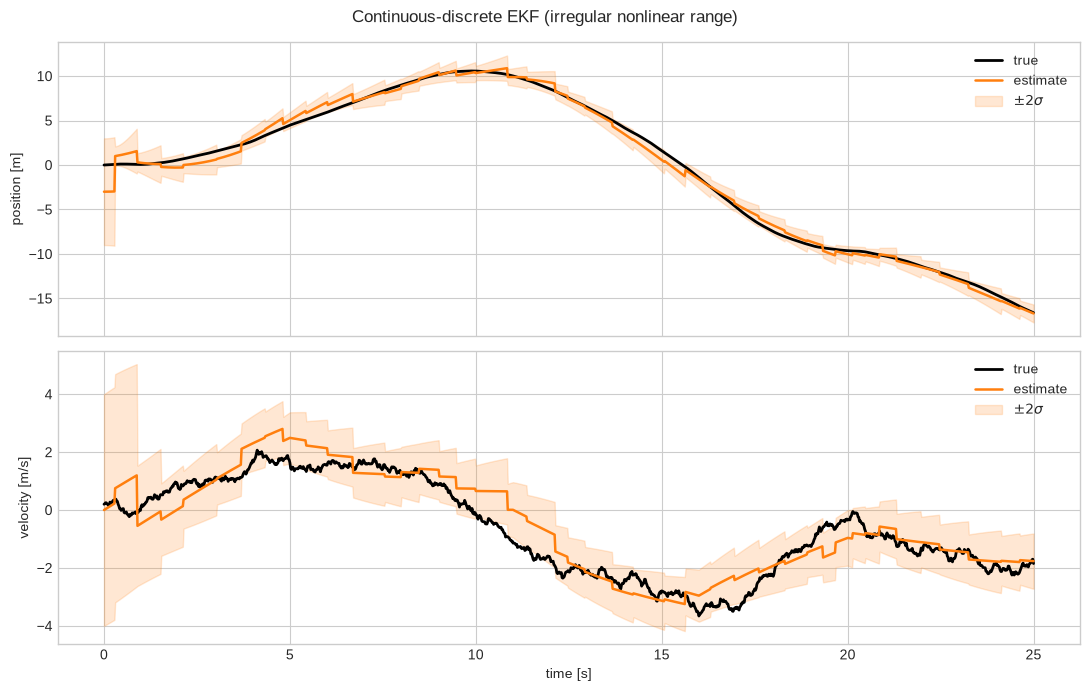

RMSE = [0.6483 0.5933]


In [9]:
# Create another irregular schedule, now for nonlinear range measurements.
range_mask=np.zeros(N,dtype=bool); next_time=.3
rng_range_times=np.random.default_rng(99)
while next_time<=T:
    range_mask[np.argmin(abs(t-next_time))]=True
    next_time += rng_range_times.uniform(.3,.9)
range_mask[0]=True
xhat_cdekf=np.zeros((N,2)); xhat_cdekf[0]=[-3.,0.]
P_cdekf=np.zeros((N,2,2)); P_cdekf[0]=np.diag([9.,4.])
for k in range(N-1):
    # Continuous nonlinear propagation happens at every simulation step.
    F=F_cont(xhat_cdekf[k])
    xhat_cdekf[k+1]=xhat_cdekf[k]+dt*f_cont(xhat_cdekf[k],u[k])
    P_cdekf[k+1]=P_cdekf[k]+dt*(F@P_cdekf[k]+P_cdekf[k]@F.T+Qc)
    if range_mask[k+1]:
        # A measurement arrival triggers an instantaneous discrete EKF update.
        H=H_range(xhat_cdekf[k+1])
        residual=range_meas[k+1]-h_range(xhat_cdekf[k+1])
        S=H@P_cdekf[k+1]@H.T+R_r
        K=P_cdekf[k+1]@H.T@np.linalg.inv(S)
        xhat_cdekf[k+1]+=K[:,0]*residual
        J=np.eye(2)-K@H
        P_cdekf[k+1]=J@P_cdekf[k+1]@J.T+K@R_r@K.T
idx_range=np.flatnonzero(range_mask)
plot_estimate(t,truth,xhat_cdekf,'Continuous-discrete EKF (irregular nonlinear range)',
              sigma=np.sqrt(np.maximum(np.diagonal(P_cdekf,axis1=1,axis2=2),0)))
print('RMSE =',rmse(xhat_cdekf,truth))

## 7. Observability (Section 2.10)

Before trusting any filter, we must ask whether the available measurements contain enough information to recover the state. For the linear position/velocity model, GPS measures only position. Yet velocity is observable because it changes future position. For sample time $h$,

$$\mathcal O=\begin{bmatrix}C\\CA\end{bmatrix}=\begin{bmatrix}1&0\\1&h\end{bmatrix}.$$

It has rank 2 whenever $h\ne0$.

### Why velocity can be reconstructed

At the first sample, GPS gives

$$z_0=Cx_0=p_0.$$

At the next sample,

$$z_1=CAx_0=p_0+hv_0.$$

Therefore, in the noise-free case,

$$p_0=z_0,\qquad v_0=\frac{z_1-z_0}{h}.$$

Equivalently, $\det(\mathcal O)=h$. For $h\ne0$, the determinant is nonzero, so $\operatorname{rank}(\mathcal O)=2$, equal to the state dimension. The code verifies exactly this rank condition with `np.linalg.matrix_rank`.

![](observability_position_reveals_velocity.gif)

### Interpretation

Observability is a property of the model and measurements, not of the filter tuning. A more sophisticated filter cannot recover a state that never influences any measurement. Check observability before spending time tuning $Q$, $R$, or gains. In nonlinear systems, observability can also depend on the trajectory; some robot motions reveal parameters that stationary motion cannot.


In [10]:
# Stack C and C@A. With two states, two block rows are sufficient for the
# standard linear time-invariant observability rank test.
O=np.vstack((C,C@A))
print('A =\n',A)
print('C =\n',C)
print('Observability matrix =\n',O)
print('rank(O) =',np.linalg.matrix_rank(O),'  state dimension =',A.shape[0])
print('Observable?',np.linalg.matrix_rank(O)==A.shape[0])

C_bad=np.array([[0.,0.]])
O_bad=np.vstack((C_bad,C_bad@A))
print('\nWith a sensor that sees no state, rank =',np.linalg.matrix_rank(O_bad))

A =
 [[1.  0.5]
 [0.  1. ]]
C =
 [[1. 0.]]
Observability matrix =
 [[1.  0. ]
 [1.  0.5]]
rank(O) = 2   state dimension = 2
Observable? True

With a sensor that sees no state, rank = 0


## 8. Luenberger observer (Section 2.11)

A Kalman filter is not the only predict-and-correct estimator. If a probabilistic noise model is unavailable, we can design a deterministic observer by choosing how quickly its error should decay. For $A_c=[[0,1],[0,0]]$ and $C=[1,0]$, choosing observer poles at $-2$ and $-3$ gives $L=[5,6]^T$. Unlike the KF, this gain comes from desired error dynamics rather than $Q$ and $R$.

### Choose the observer gain step by step

The observer is $\dot{\hat x}=A_c\hat x+B_cu+L(z-C\hat x)$. With error $\tilde x=x-\hat x$, subtracting observer dynamics from true dynamics gives

$$\dot{\tilde x}=(A_c-LC)\tilde x.$$

Let $L=[l_1,l_2]^T$. Then

$$A_c-LC=\begin{bmatrix}-l_1&1\\-l_2&0\end{bmatrix}.$$

Its characteristic polynomial is

$$\det(\lambda I-(A_c-LC))=\lambda^2+l_1\lambda+l_2.$$

Desired poles $-2,-3$ give $(\lambda+2)(\lambda+3)=\lambda^2+5\lambda+6$. Matching coefficients gives $l_1=5$, $l_2=6$, which is the `L` used by the code.

![](luenberger_observer_pole_placement.gif)

### What to observe and when to use it

The selected negative poles make initial error decay, while aggressive poles also pass more measurement noise into the estimate. Use a Luenberger observer for observable linear deterministic systems when you want direct control of convergence speed and do not need covariance or a statistical interpretation.


Eigenvalues of A-LC: [-3.+0.j -2.+0.j]


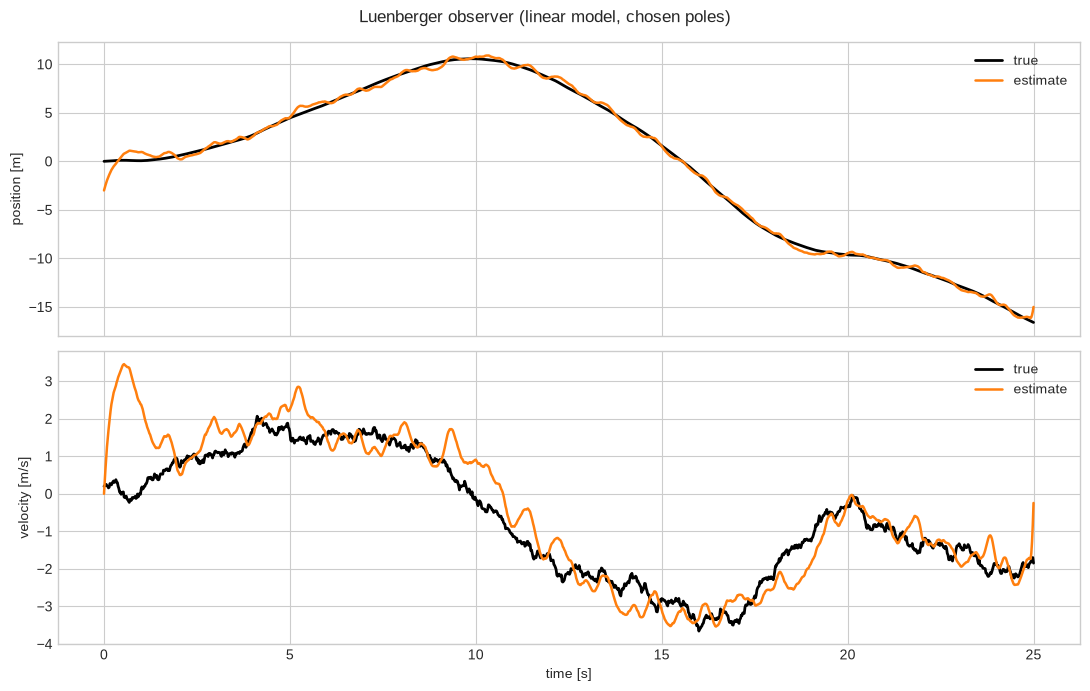

RMSE = [0.3683 0.7758]


In [11]:
# These gains place the error-system eigenvalues at -2 and -3. Negative
# continuous-time eigenvalues make estimation error decay toward zero.
L=np.array([5.,6.])
print('Eigenvalues of A-LC:',np.linalg.eigvals(Ac-np.outer(L,C[0])))
xhat_l=np.zeros((N,2)); xhat_l[0]=[-3.,0.]
# Smooth the raw GPS slightly only to make a continuous-measurement demonstration readable.
gps_smooth=np.convolve(gps,np.ones(11)/11,mode='same')
for k in range(N-1):
    # Same predict-plus-correct structure as a continuous KF, but L is fixed
    # by pole placement rather than calculated from Q, R, and P.
    residual=gps_smooth[k]-xhat_l[k,0]
    xhat_l[k+1]=xhat_l[k]+dt*(Ac@xhat_l[k]+Bc*u[k]+L*residual)
plot_estimate(t,truth,xhat_l,'Luenberger observer (linear model, chosen poles)')
print('RMSE =',rmse(xhat_l,truth))

## 9. Nonlinear observer (Section 2.12)

Finally, we keep the deterministic observer idea but stop forcing the robot into a linear model. We copy the true nonlinear drag model and add a deterministic correction from GPS error:

$$\dot{\hat p}=\hat v+l_1(z_p-\hat p),$$
$$\dot{\hat v}=u-c\hat v|\hat v|+l_2(z_p-\hat p).$$

This is a simple nonlinear observer, not an EKF: there is no covariance, no Riccati equation, and no probabilistic gain calculation. The gains are design parameters.

### Understand why the nonlinear correction works

Ignoring noise for the derivation, define $e_p=p-\hat p$ and $e_v=v-\hat v$. Subtracting observer equations from the real nonlinear dynamics gives

$$\dot e_p=e_v-l_1e_p,$$
$$\dot e_v=-c\left(v|v|-\hat v|\hat v|\right)-l_2e_p.$$

The first equation shows that position residual feedback directly reduces position error. The second shows that the same residual also corrects velocity, while copying nonlinear drag reduces model mismatch. Near $v=\hat v$, the drag difference can be locally approximated as

$$v|v|-\hat v|\hat v|\approx2|\hat v|e_v,$$

so the local error dynamics are approximately

$$\begin{bmatrix}\dot e_p\\\dot e_v\end{bmatrix}\approx\begin{bmatrix}-l_1&1\\-l_2&-2c|\hat v|\end{bmatrix}\begin{bmatrix}e_p\\e_v\end{bmatrix}.$$

Unlike the Luenberger observer, this matrix changes with velocity. Unlike the EKF, the code does not maintain a probabilistic covariance; `L_nl` is tuned directly for convergence and noise sensitivity.

![](nonlinear_observer_fixed_gain.gif)

### What to observe and when to use it

The observer follows nonlinear drag without maintaining $P$. Its behavior depends directly on the chosen gains. Use a nonlinear observer when system geometry or stability analysis provides a suitable correction law, especially when formal convergence matters more than a probabilistic uncertainty estimate. Attitude complementary filters are an important robotics example.


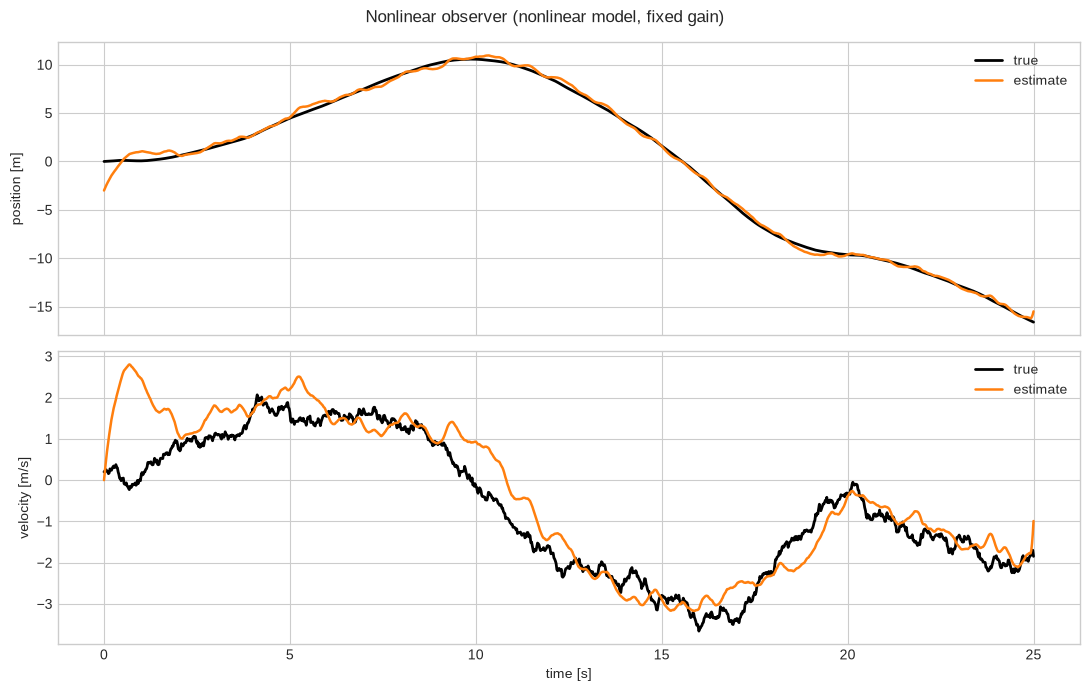

RMSE = [0.3823 0.7058]


In [12]:
# Fixed deterministic correction gains chosen for a useful speed/noise tradeoff.
L_nl=np.array([3.2,3.0])
xhat_no=np.zeros((N,2)); xhat_no[0]=[-3.,0.]
for k in range(N-1):
    # The observer copies nonlinear physics and injects measured output error.
    # There is deliberately no P, Q, R, Kalman gain, or Riccati equation here.
    residual=gps_smooth[k]-xhat_no[k,0]
    xhat_no[k+1]=xhat_no[k]+dt*(f_cont(xhat_no[k],u[k])+L_nl*residual)
plot_estimate(t,truth,xhat_no,'Nonlinear observer (nonlinear model, fixed gain)')
print('RMSE =',rmse(xhat_no,truth))

## 10. Put the full picture together

We have now seen several algorithms, but they all share one central idea:

$$\boxed{\text{use physics to predict, use sensors to detect error, then correct}}$$

A probabilistic filter carries two coupled objects:

- $\hat x$: what the filter currently believes about the robot;
- $P$: how uncertain the filter believes that estimate is.

### The complete estimation cycle

1. **Define the state.** Include only quantities needed by the model and task, such as position, velocity, orientation, or sensor bias.
2. **Propagate the state.** Use commands and dynamics to predict where the state moves.
3. **Propagate uncertainty.** Dynamics reshape old uncertainty and process noise $Q$ adds new uncertainty.
4. **Predict the sensor.** Compute what the sensor should report from the predicted state.
5. **Form the innovation.** Subtract predicted measurement from actual measurement.
6. **Evaluate innovation uncertainty.** Combine projected state uncertainty with measurement noise $R$ to obtain $S$.
7. **Calculate correction strength.** The Kalman gain $K$ balances confidence in prediction and measurement.
8. **Correct state and covariance.** Apply the innovation and record the reduced posterior uncertainty.
9. **Repeat at the next timestamp.**

This cycle is visible in the code as **propagation variables** (`xhat`, `P`) followed by **measurement variables** (`residual`, `S`, `K`) and an update.

### How to choose an estimator

| Situation | Good starting choice | Reason |
|---|---|---|
| Linear model, fixed sampled data | Discrete KF | Exact linear probabilistic solution under Gaussian assumptions |
| Linear continuous model, irregular sensor packets | Continuous-discrete KF | Integrates motion between actual sensor timestamps |
| Nonlinear sampled model or sensor | Discrete EKF | Uses nonlinear prediction with local Jacobians |
| Nonlinear continuous motion plus asynchronous sensors | Continuous-discrete EKF | Standard practical architecture for many robots |
| Linear deterministic system, covariance not needed | Luenberger observer | Direct pole-placement control of convergence |
| Nonlinear/geometric system with known stability design | Nonlinear observer | Can respect geometry and provide analytical convergence properties |
| Strong nonlinearity, ambiguity, or poor initial estimate | EKF may not be enough | Consider better initialization, iterated EKF, UKF, particle filter, or optimization methods |

### KF or EKF?

Use a KF when both transitions and measurements can be written as linear maps. Use an EKF when either is nonlinear and a local tangent approximation is accurate near the current estimate. The EKF is not automatically better: if the system is actually linear, the ordinary KF is simpler and avoids linearization errors.

### Kalman filter or observer?

Choose a Kalman filter when sensor noise, uncertainty bounds, multi-sensor weighting, or probabilistic reasoning matter. Choose an observer when a deterministic model and convergence design are more important, or when geometry gives a natural nonlinear correction law. Some real systems combine both ideas.

### Moving from this simulation to a real robot

1. Replace synthetic `gps` and `range_meas` arrays with timestamped sensor messages.
2. Confirm units, coordinate frames, and sign conventions before tuning anything.
3. Propagate using the actual elapsed time $\Delta t$, not an assumed constant interval.
4. Derive $f$, $h$, and every Jacobian on paper; verify Jacobians numerically with finite differences.
5. Estimate $R$ from stationary sensor data and choose $Q$ to represent unmodeled motion, not merely to make a plot look smooth.
6. Reject or gate impossible measurements using the normalized innovation.
7. Monitor covariance, innovations, dropped messages, and numerical health online.
8. Compare estimates against independent ground truth before deployment.

### Common mistakes to recognize

- Confusing the true state with the estimate. Real filters never receive `truth`.
- Using a measurement without first predicting what that sensor should observe.
- Mixing continuous noise intensity $Q_c,R_c$ with discrete covariance $Q,R$.
- Using the Jacobian $H\hat x$ instead of nonlinear prediction $h(\hat x)$.
- Evaluating EKF Jacobians at an old or incorrect state.
- Tuning an estimator for a fundamentally unobservable state.
- Treating small $P$ as proof of accuracy; a wrong model can be confidently wrong.
- Ignoring timestamps and asynchronous sensor arrival.

The bar plot below summarizes error for this particular simulation. It is evidence about this experiment, not a universal ranking of algorithms. Different methods here also receive different measurement schedules, so use the plot to inspect behavior rather than declare one permanent winner.
![](all_estimators_rmse_comparison.gif)


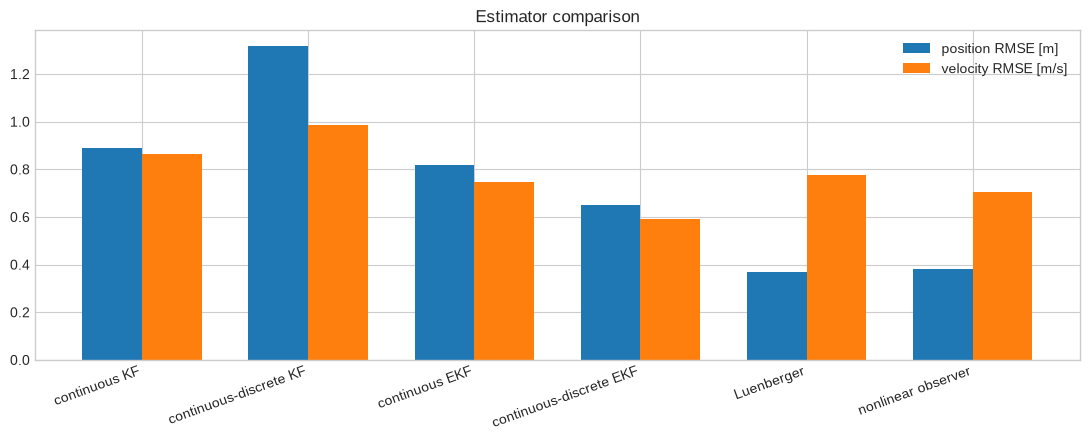

continuous KF               : position=0.890, velocity=0.862
continuous-discrete KF      : position=1.317, velocity=0.985
continuous EKF              : position=0.819, velocity=0.745
continuous-discrete EKF     : position=0.648, velocity=0.593
Luenberger                  : position=0.368, velocity=0.776
nonlinear observer          : position=0.382, velocity=0.706


In [13]:
# Put methods that produce an estimate at every simulation time into one list.
# The purely discrete filters are plotted in their own sections because their
# estimates exist only at measurement times in this teaching implementation.
names=['continuous KF','continuous-discrete KF','continuous EKF',
       'continuous-discrete EKF','Luenberger','nonlinear observer']
estimates=[xhat_ct,xhat_cd,xhat_cekf,xhat_cdekf,xhat_l,xhat_no]
# Each row becomes [position RMSE, velocity RMSE].
scores=np.array([rmse(e,truth) for e in estimates])
xpos=np.arange(len(names)); width=.36
fig,ax=plt.subplots(figsize=(11,4.5))
ax.bar(xpos-width/2,scores[:,0],width,label='position RMSE [m]')
ax.bar(xpos+width/2,scores[:,1],width,label='velocity RMSE [m/s]')
ax.set_xticks(xpos,names,rotation=20,ha='right'); ax.legend(); ax.set_title('Estimator comparison')
plt.tight_layout(); plt.show()
for name,score in zip(names,scores): print(f'{name:28s}: position={score[0]:.3f}, velocity={score[1]:.3f}')

## Experiments to try yourself

1. Increase `gps_std` from 1.2 to 4.0. Does the Kalman gain give GPS less influence?
2. Increase `q_acc`. Does covariance grow faster between measurements?
3. Set the initial estimate to `[40, 0]`. Can the range-only EKF recover, or does landmark-range ambiguity cause trouble?
4. Change the GPS interval from 0.5 s to 2 s. Observe the uncertainty between updates.
5. Set `drag = 0`. Do the KF and EKF become more similar?
6. Change the Luenberger poles and observe the speed/noise trade-off.
7. Remove GPS updates for five seconds and inspect how $P$ grows.

For a real system, replace the truth simulator and synthetic measurements with timestamped sensor readings. Keep the estimator functions, propagate using the actual time difference, and update only when a new sensor message arrives.